# Model A + VGS: main figures notebook

This notebook produces the main deterministic/VGS figures for the paper.

It follows the working local API style used in the earlier notebooks:
- random diagonal-anisotropic target family via make_diag_anisotropic_spec(...)
- constant-beta scans
- warm-started hierarchical optimization 1 -> 2 -> 4 -> 8
- step-function plots for beta(t)

The focus here is entirely on the deterministic VGS objective.
No spread-based objective is used in this notebook.

## Imports and repository bootstrap

In [1]:
import json
import sys
from pathlib import Path

ROOT = Path.cwd().resolve()
if not (ROOT / "lqgm_pid_ada").exists():
    for parent in [ROOT, *ROOT.parents]:
        if (parent / "lqgm_pid_ada").exists():
            ROOT = parent
            break

if not (ROOT / "lqgm_pid_ada").exists():
    raise RuntimeError("Could not locate `lqgm_pid_ada`.")

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from IPython.display import display

from lqgm_pid_ada import (
    LQGMPID,
    auto_correlation,
    exact_marginal_gmm,
    make_diag_anisotropic_spec,
    make_pwc_beta_spec,
)

## Global settings

In [2]:
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.set_default_dtype(torch.float64)
DEVICE = "cpu"

# Model A family
K = 4
RADIUS = 3.0
SCALE = 0.6
COND = 20.0

# Main dimensions for paper
DIMS_MAIN = [2, 8]
DIMS_SCALING = [2, 4, 8, 16]

# Protocol hierarchy
LEVELS = [1, 2, 4, 8]
BETA_INIT = 1.0
BETA_MIN = 0.05
BETA_MAX = 20.0

# Constant-beta scans
CONST_GRID_D2 = [0.05, 0.1, 0.2, 0.3, 0.5, 0.8, 1.0, 1.5, 2.5, 4.0, 6.0, 8.0, 12.0, 16.0, 20.0]
CONST_GRID_D8 = [0.05, 0.1, 0.2, 0.3, 0.5, 0.8, 1.0, 1.5, 2.5, 4.0, 6.0, 8.0, 12.0, 16.0, 20.0]
CONST_GRID_BY_D = {
    2: CONST_GRID_D2,
    4: CONST_GRID_D8,
    8: CONST_GRID_D8,
    16: CONST_GRID_D8,
}

# Deterministic evaluation grid
TIME_GRID_DET = np.linspace(0.05, 0.95, 24)
MAX_COMPONENTS_VGS = 6

# Stochastic memory curve budget for visual support only
B_AC = 768
N_STEPS_AC = 320
SEED_SIM = 20241012

# Coordinate descent
STEP0 = 0.6
STEP_MIN = 1e-4
IMPROVE_TOL = 5e-4
MAX_SWEEPS = 20

# Output
FIG_DIR = ROOT / "figs" / "modelA_vgs_main"
TABLE_DIR = ROOT / "tables" / "modelA_vgs_main"
FIG_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams["figure.figsize"] = (6, 4)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25
plt.rcParams["savefig.dpi"] = 220

## Output helpers

In [3]:
def savefig_all(fig, stem: str, folder=FIG_DIR, close=False):
    pdf_path = folder / f"{stem}.pdf"
    png_path = folder / f"{stem}.png"
    fig.savefig(pdf_path, bbox_inches="tight")
    fig.savefig(png_path, bbox_inches="tight")
    print(f"saved: {pdf_path}")
    print(f"saved: {png_path}")
    if close:
        plt.close(fig)

def save_table(df: pd.DataFrame, stem: str, folder=TABLE_DIR):
    csv_path = folder / f"{stem}.csv"
    tex_path = folder / f"{stem}.tex"
    df.to_csv(csv_path, index=False)
    try:
        df.to_latex(tex_path, index=False, float_format=lambda x: f"{x:.6g}")
    except Exception:
        pass
    print(f"saved: {csv_path}")

def save_json(obj, stem: str, folder=TABLE_DIR):
    path = folder / f"{stem}.json"
    with open(path, "w", encoding="utf-8") as f:
        json.dump(obj, f, indent=2)
    print(f"saved: {path}")

## Model A builders

In [4]:
def benchmark_spec(d: int):
    return make_diag_anisotropic_spec(
        d=d,
        K=K,
        radius=RADIUS,
        scale=SCALE,
        cond=COND,
        seed=SEED,
    )

def build_target(d: int):
    return benchmark_spec(d).build().to(device=DEVICE, dtype=torch.float64)

def build_pid(d: int, beta_values):
    target = build_target(d)
    pspec = make_pwc_beta_spec(
        d=d,
        breaks=np.linspace(0.0, 1.0, len(beta_values) + 1).tolist(),
        beta_values=list(np.asarray(beta_values, dtype=float)),
        family="optimized_pwc",
        device=DEVICE,
        dtype=torch.float64,
    )
    proto = pspec.build()
    x0 = torch.zeros(d, device=DEVICE, dtype=torch.float64)
    pid = LQGMPID(proto, target, x0)
    pid.precompute()
    return pid

## VGS and memory-curve diagnostics

In [5]:
def control_jacobian_single(pid, t, x):
    x = x.detach().clone().requires_grad_(True)
    u = pid.control(t, x.unsqueeze(0)).squeeze(0)
    d = x.numel()
    rows = []
    for j in range(d):
        (grad_j,) = torch.autograd.grad(
            u[j], x, retain_graph=(j < d - 1), create_graph=False, allow_unused=False
        )
        rows.append(grad_j.unsqueeze(0))
    return torch.cat(rows, dim=0)

def deterministic_vgs(d: int, beta_values, time_grid=TIME_GRID_DET, max_components_eval=MAX_COMPONENTS_VGS):
    pid = build_pid(d, beta_values)
    vals_t, tvals = [], []

    for t in time_grid:
        gm = exact_marginal_gmm(pid, float(t))
        weights = gm["weights"]
        means = gm["means"]

        if weights.numel() > max_components_eval:
            idx = torch.argsort(weights, descending=True)[:max_components_eval]
            weights_use = weights[idx]
            weights_use = weights_use / weights_use.sum()
            means_use = means[idx]
        else:
            weights_use = weights
            means_use = means

        t_tensor = torch.as_tensor(float(t), device=means.device, dtype=means.dtype)
        vgs_t = 0.0
        for wk, mk in zip(weights_use, means_use):
            J = control_jacobian_single(pid, t_tensor, mk)
            vgs_t += float(wk.detach().cpu().item()) * float(J.square().sum().detach().cpu().item())

        vals_t.append(vgs_t)
        tvals.append(float(t))

    return float(np.trapz(vals_t, tvals))

def interpolated_crossing_time(times, values, threshold=0.8, append_terminal_one=True):
    times = np.asarray(times, dtype=float)
    values = np.asarray(values, dtype=float)

    if append_terminal_one and times[-1] < 1.0:
        times = np.concatenate([times, [1.0]])
        values = np.concatenate([values, [1.0]])

    idx = np.where(values >= threshold)[0]
    if len(idx) == 0:
        return 1.0

    i = idx[0]
    if i == 0:
        return float(times[0])

    t0, t1 = times[i - 1], times[i]
    y0, y1 = values[i - 1], values[i]
    if abs(y1 - y0) < 1e-14:
        return float(t1)

    alpha = (threshold - y0) / (y1 - y0)
    alpha = np.clip(alpha, 0.0, 1.0)
    return float(t0 + alpha * (t1 - t0))

def evaluate_memory_curve(d: int, beta_values, B=B_AC, n_steps=N_STEPS_AC, seed=SEED_SIM):
    pid = build_pid(d, beta_values)
    sim = pid.simulate(B=B, n_steps=n_steps, seed=int(seed), dtype=torch.float64, device=DEVICE)
    ac = auto_correlation(pid, sim=sim, threshold=0.8)
    t = ac.times.detach().cpu().numpy()
    Ahat = ac.Ahat.detach().cpu().numpy()
    return {
        "times": t,
        "Ahat": Ahat,
        "t_cross_Ahat_08": interpolated_crossing_time(t, Ahat, threshold=0.8, append_terminal_one=True),
    }

def evaluate_vgs_row(d: int, beta_values, kind: str, extra=None):
    Jvgs = deterministic_vgs(d, beta_values)
    mem = evaluate_memory_curve(d, beta_values)

    row = {
        "d": d,
        "kind": kind,
        "betas": np.array2string(np.asarray(beta_values, dtype=float), precision=6, separator=", "),
        "J_VGS": Jvgs,
        "J_VGS_per_d": Jvgs / d,
        "t_cross_Ahat_08": mem["t_cross_Ahat_08"],
    }
    if extra is not None:
        row.update(extra)
    return row, mem

## Coordinate descent for deterministic VGS

In [6]:
def objective_vgs(d, beta_values):
    return deterministic_vgs(d, beta_values)

def coord_descent_vgs(
    d,
    betas0,
    step0=STEP0,
    step_min=STEP_MIN,
    improve_tol=IMPROVE_TOL,
    max_sweeps=MAX_SWEEPS,
    beta_min=BETA_MIN,
    beta_max=BETA_MAX,
    record=None,
):
    b = np.asarray(betas0, dtype=float).copy()
    fbest = objective_vgs(d, b)
    if record is not None:
        record.append(float(fbest))

    step = float(step0)
    for _ in range(max_sweeps):
        improved = False
        for k in range(len(b)):
            for sgn in (+1, -1):
                cand = b.copy()
                cand[k] = np.clip(cand[k] + sgn * step, beta_min, beta_max)
                f = objective_vgs(d, cand)
                if f + improve_tol < fbest:
                    b, fbest = cand, f
                    improved = True
                    if record is not None:
                        record.append(float(fbest))
        if not improved:
            step *= 0.5
            if step < step_min:
                break
    return b, float(fbest)

def prolongate_parent_to_children(parent_betas, L):
    parent_betas = np.asarray(parent_betas, dtype=float)
    if len(parent_betas) == L:
        return parent_betas.copy()

    splitsL = np.linspace(0.0, 1.0, L + 1)
    parent_edges = np.linspace(0.0, 1.0, len(parent_betas) + 1)

    child = np.empty(L, dtype=float)
    for i in range(L):
        t_mid = 0.5 * (splitsL[i] + splitsL[i + 1])
        j = np.searchsorted(parent_edges, t_mid, side="right") - 1
        j = max(0, min(len(parent_betas) - 1, j))
        child[i] = parent_betas[j]
    return child

def step_plot_from_betas(betas):
    betas = np.asarray(betas, dtype=float)
    L = len(betas)
    edges = np.linspace(0.0, 1.0, L + 1)
    x = np.repeat(edges, 2)[1:-1]
    y = np.repeat(betas, 2)
    return x, y

## Target visuals in d=2

saved: /Users/chertkov/Dropbox/Working/NewPID/NewAdaPID-final/figs/modelA_vgs_main/fig_modelA_target_d2.pdf
saved: /Users/chertkov/Dropbox/Working/NewPID/NewAdaPID-final/figs/modelA_vgs_main/fig_modelA_target_d2.png


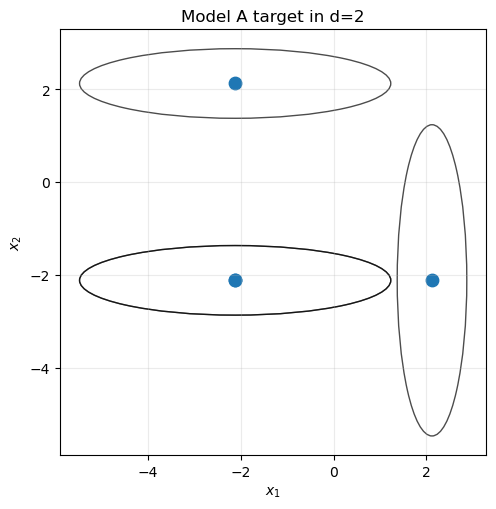

In [7]:
def plot_target_visual_d2():
    d = 2
    target = build_target(d)
    means = target.means.detach().cpu().numpy()
    covs = target.covs.detach().cpu().numpy()

    fig, ax = plt.subplots(figsize=(5.2, 5.2))
    ax.scatter(means[:, 0], means[:, 1], s=80)

    for m, C in zip(means, covs):
        vals, vecs = np.linalg.eigh(C)
        angle = np.degrees(np.arctan2(vecs[1, 1], vecs[0, 1]))
        width, height = 2.5 * np.sqrt(vals[1]), 2.5 * np.sqrt(vals[0])
        from matplotlib.patches import Ellipse
        e = Ellipse(xy=m, width=width, height=height, angle=angle, fill=False, alpha=0.7)
        ax.add_patch(e)

    ax.set_title("Model A target in d=2")
    ax.set_xlabel(r"$x_1$")
    ax.set_ylabel(r"$x_2$")
    ax.set_aspect("equal", adjustable="box")
    plt.tight_layout()
    savefig_all(fig, "fig_modelA_target_d2")

plot_target_visual_d2()

## Constant-beta scans for d=2 and d=8

In [8]:
const_rows = []
const_artifacts = {}

for d in DIMS_MAIN:
    print("=" * 80)
    print(f"Constant-beta scan for Model A, d={d}")
    for beta in CONST_GRID_BY_D[d]:
        beta_values = [beta]
        row, mem = evaluate_vgs_row(
            d,
            beta_values,
            kind="constant_scan",
            extra={"beta_const": beta},
        )
        const_rows.append(row)
        const_artifacts[(d, beta)] = mem
        print(
            f"d={d} | beta={beta:>5g} | "
            f"J_VGS/d={row['J_VGS_per_d']:.6f} | "
            f"t_cross={row['t_cross_Ahat_08']:.4f}"
        )

const_df = pd.DataFrame(const_rows).sort_values(["d", "beta_const"]).reset_index(drop=True)
display(const_df)
save_table(const_df, "constant_beta_scan_modelA_vgs")

Constant-beta scan for Model A, d=2
d=2 | beta= 0.05 | J_VGS/d=3.642134 | t_cross=0.2774
d=2 | beta=  0.1 | J_VGS/d=3.595521 | t_cross=0.2793
d=2 | beta=  0.2 | J_VGS/d=3.506653 | t_cross=0.2828
d=2 | beta=  0.3 | J_VGS/d=3.418993 | t_cross=0.2858
d=2 | beta=  0.5 | J_VGS/d=3.249382 | t_cross=0.2957
d=2 | beta=  0.8 | J_VGS/d=3.014238 | t_cross=0.3067
d=2 | beta=    1 | J_VGS/d=2.867968 | t_cross=0.3124
d=2 | beta=  1.5 | J_VGS/d=2.539324 | t_cross=0.3283
d=2 | beta=  2.5 | J_VGS/d=2.043872 | t_cross=0.3689
d=2 | beta=    4 | J_VGS/d=1.652519 | t_cross=0.4188
d=2 | beta=    6 | J_VGS/d=1.640266 | t_cross=0.4701
d=2 | beta=    8 | J_VGS/d=2.034511 | t_cross=0.5166
d=2 | beta=   12 | J_VGS/d=3.548759 | t_cross=0.5767
d=2 | beta=   16 | J_VGS/d=5.593450 | t_cross=0.6145
d=2 | beta=   20 | J_VGS/d=7.918148 | t_cross=0.6389
Constant-beta scan for Model A, d=8
d=8 | beta= 0.05 | J_VGS/d=1.297370 | t_cross=0.4617
d=8 | beta=  0.1 | J_VGS/d=1.276805 | t_cross=0.4637
d=8 | beta=  0.2 | J_VGS/d=

,d,kind,betas,J_VGS,J_VGS_per_d,t_cross_Ahat_08,beta_const
0,2,constant_scan,[0.05],7.284268,3.642134,0.277362,0.05
1,2,constant_scan,[0.1],7.191043,3.595521,0.279340,0.10
2,2,constant_scan,[0.2],7.013306,3.506653,0.282751,0.20
3,2,constant_scan,[0.3],6.837985,3.418993,0.285843,0.30
4,2,constant_scan,[0.5],6.498765,3.249382,0.295745,0.50
5,2,constant_scan,[0.8],6.028476,3.014238,0.306679,0.80
6,2,constant_scan,[1.],5.735936,2.867968,0.312363,1.00
7,2,constant_scan,[1.5],5.078649,2.539324,0.328330,1.50
8,2,constant_scan,[2.5],4.087744,2.043872,0.368866,2.50
9,2,constant_scan,[4.],3.305038,1.652519,0.418800,4.00


saved: /Users/chertkov/Dropbox/Working/NewPID/NewAdaPID-final/tables/modelA_vgs_main/constant_beta_scan_modelA_vgs.csv


### Best constant beta per main dimension

In [9]:
best_const_df = (
    const_df.sort_values(["d", "J_VGS"])
            .groupby("d", as_index=False)
            .first()
)
display(best_const_df)
save_table(best_const_df, "best_constant_per_dimension_modelA_vgs")

,d,kind,betas,J_VGS,J_VGS_per_d,t_cross_Ahat_08,beta_const
0,2,constant_scan,[6.],3.280533,1.640266,0.470119,6.0
1,8,constant_scan,[2.5],7.011213,0.876402,0.542512,2.5


saved: /Users/chertkov/Dropbox/Working/NewPID/NewAdaPID-final/tables/modelA_vgs_main/best_constant_per_dimension_modelA_vgs.csv


### Constant-beta plots

saved: /Users/chertkov/Dropbox/Working/NewPID/NewAdaPID-final/figs/modelA_vgs_main/fig_modelA_const_scan_d2.pdf
saved: /Users/chertkov/Dropbox/Working/NewPID/NewAdaPID-final/figs/modelA_vgs_main/fig_modelA_const_scan_d2.png
saved: /Users/chertkov/Dropbox/Working/NewPID/NewAdaPID-final/figs/modelA_vgs_main/fig_modelA_const_scan_d8.pdf
saved: /Users/chertkov/Dropbox/Working/NewPID/NewAdaPID-final/figs/modelA_vgs_main/fig_modelA_const_scan_d8.png


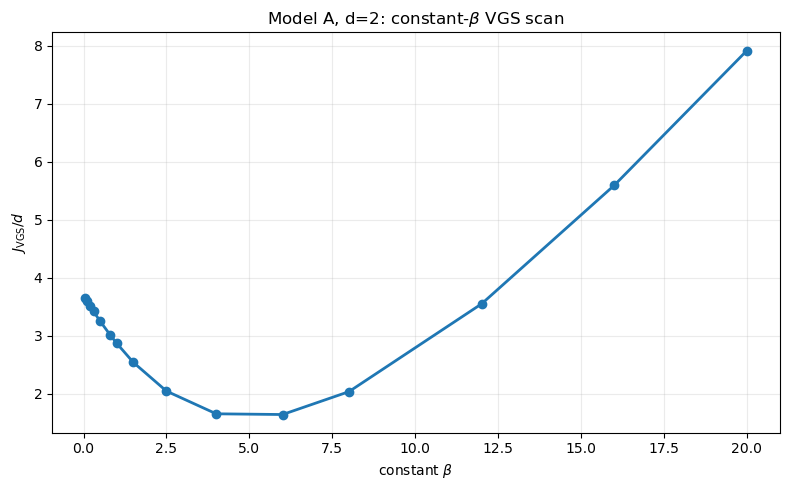

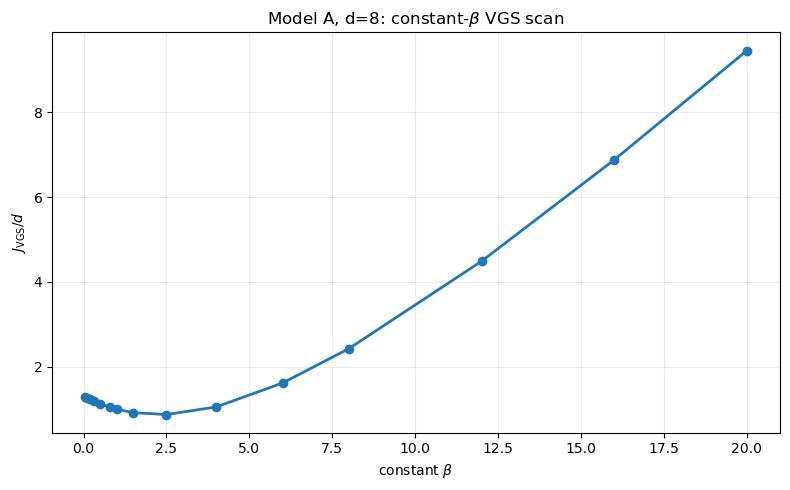

In [10]:
for d in DIMS_MAIN:
    sub = const_df[const_df["d"] == d].sort_values("beta_const")

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(sub["beta_const"], sub["J_VGS_per_d"], marker="o", linewidth=2)
    ax.set_xlabel(r"constant $\beta$")
    ax.set_ylabel(r"$J_{\mathrm{VGS}}/d$")
    ax.set_title(fr"Model A, d={d}: constant-$\beta$ VGS scan")
    plt.tight_layout()
    savefig_all(fig, f"fig_modelA_const_scan_d{d}")

## Hierarchical VGS optimization starting from best constant beta

In [11]:
hier_rows = []
hier_best_records = {}
hier_series = {}

for d in DIMS_MAIN:
    print("=" * 80)
    print(f"Hierarchical VGS optimization for d={d}")

    best_const_row = best_const_df[best_const_df["d"] == d].iloc[0]
    b_parent = np.array([float(best_const_row["beta_const"])], dtype=float)

    traj_f = []
    level_marks = []
    level_records = {}

    for L in LEVELS:
        if L == 1:
            b_init = b_parent.copy()
        else:
            b_init = prolongate_parent_to_children(b_parent, L)

        start_idx = len(traj_f)
        b_star, f_star = coord_descent_vgs(d, b_init, record=traj_f)
        level_marks.append(start_idx)

        row, mem = evaluate_vgs_row(
            d,
            b_star,
            kind="hierarchical_vgs",
            extra={"L": L, "objective_value": f_star},
        )
        level_records[L] = {
            "row": row,
            "mem": mem,
            "betas": np.asarray(b_star, dtype=float).copy(),
        }
        hier_rows.append(row)

        print(
            f"[d={d}, L={L}] "
            f"J_VGS={row['J_VGS']:.6f}, "
            f"t_cross={row['t_cross_Ahat_08']:.4f}, beta*={np.array2string(np.asarray(b_star), precision=4)}"
        )
        b_parent = np.asarray(b_star, dtype=float).copy()

    hier_best_records[d] = level_records
    hier_series[d] = {
        "traj_f": np.asarray(traj_f, dtype=float),
        "level_marks": np.asarray(level_marks, dtype=int),
    }

hier_df = pd.DataFrame(hier_rows).sort_values(["d", "L"]).reset_index(drop=True)
display(hier_df)
save_table(hier_df, "hierarchical_vgs_summary_modelA")

Hierarchical VGS optimization for d=2
[d=2, L=1] J_VGS=3.169223, t_cross=0.4509, beta*=[4.9875]
[d=2, L=2] J_VGS=3.169405, t_cross=0.4509, beta*=[4.9875 4.9875]
[d=2, L=4] J_VGS=3.088615, t_cross=0.4523, beta*=[0.1875 7.3875 4.9875 4.0875]
[d=2, L=8] J_VGS=3.025722, t_cross=0.4576, beta*=[ 0.1875  0.1875  3.7875 10.9875  6.1875  3.1875  1.6875 12.4875]
Hierarchical VGS optimization for d=8
[d=8, L=1] J_VGS=6.985975, t_cross=0.5357, beta*=[2.2937]
[d=8, L=2] J_VGS=6.983230, t_cross=0.5375, beta*=[2.2187 2.3875]
[d=8, L=4] J_VGS=6.933293, t_cross=0.5413, beta*=[1.9187 2.5187 1.4875 3.8875]
[d=8, L=8] J_VGS=6.749985, t_cross=0.5504, beta*=[ 0.1187  1.9187  2.5187  2.5187  1.4875  1.4875  0.2875 15.8875]


,d,kind,betas,J_VGS,J_VGS_per_d,t_cross_Ahat_08,L,objective_value
0,2,hierarchical_vgs,[4.9875],3.169223,1.584611,0.450903,1,3.169223
1,2,hierarchical_vgs,"[4.9875, 4.9875]",3.169405,1.584703,0.450933,2,3.169405
2,2,hierarchical_vgs,"[0.1875, 7.3875, 4.9875, 4.0875]",3.088615,1.544307,0.452349,4,3.088615
3,2,hierarchical_vgs,"[ 0.1875, 0.1875, 3.7875, 10.9875, 6.1875, ...",3.025722,1.512861,0.457643,8,3.025722
4,8,hierarchical_vgs,[2.29375],6.985975,0.873247,0.535670,1,6.985975
5,8,hierarchical_vgs,"[2.21875, 2.3875 ]",6.983230,0.872904,0.537512,2,6.983230
6,8,hierarchical_vgs,"[1.91875, 2.51875, 1.4875 , 3.8875 ]",6.933293,0.866662,0.541309,4,6.933293
7,8,hierarchical_vgs,"[ 0.11875, 1.91875, 2.51875, 2.51875, 1.48...",6.749985,0.843748,0.550439,8,6.749985


saved: /Users/chertkov/Dropbox/Working/NewPID/NewAdaPID-final/tables/modelA_vgs_main/hierarchical_vgs_summary_modelA.csv


### Best PWC-8 per dimension

In [12]:
best_pwc8_rows = []
for d in DIMS_MAIN:
    rec = hier_best_records[d][8]["row"]
    best_pwc8_rows.append(rec)

best_pwc8_df = pd.DataFrame(best_pwc8_rows).sort_values("d").reset_index(drop=True)
display(best_pwc8_df)
save_table(best_pwc8_df, "best_pwc8_per_dimension_modelA")

,d,kind,betas,J_VGS,J_VGS_per_d,t_cross_Ahat_08,L,objective_value
0,2,hierarchical_vgs,"[ 0.1875, 0.1875, 3.7875, 10.9875, 6.1875, ...",3.025722,1.512861,0.457643,8,3.025722
1,8,hierarchical_vgs,"[ 0.11875, 1.91875, 2.51875, 2.51875, 1.48...",6.749985,0.843748,0.550439,8,6.749985


saved: /Users/chertkov/Dropbox/Working/NewPID/NewAdaPID-final/tables/modelA_vgs_main/best_pwc8_per_dimension_modelA.csv


### Compare best constant vs best PWC-8

In [14]:
cmp_rows = []
for d in DIMS_MAIN:
    const_row = best_const_df[best_const_df["d"] == d].iloc[0]
    pwc8_row = best_pwc8_df[best_pwc8_df["d"] == d].iloc[0]

    cmp_rows.append({
        "d": d,
        "const_beta": float(const_row["beta_const"]),
        "const_J_VGS_per_d": float(const_row["J_VGS_per_d"]),
        "const_t_cross": float(const_row["t_cross_Ahat_08"]),
        "pwc8_J_VGS_per_d": float(pwc8_row["J_VGS_per_d"]),
        "pwc8_t_cross": float(pwc8_row["t_cross_Ahat_08"]),
        "pwc8_betas": pwc8_row["betas"],
        "improvement_J_VGS_per_d": float(const_row["J_VGS_per_d"]) - float(pwc8_row["J_VGS_per_d"]),
    })

cmp_df = pd.DataFrame(cmp_rows).sort_values("d").reset_index(drop=True)
display(cmp_df)
save_table(cmp_df, "best_constant_vs_best_pwc8_modelA")

,d,const_beta,const_J_VGS_per_d,const_t_cross,pwc8_J_VGS_per_d,pwc8_t_cross,pwc8_betas,improvement_J_VGS_per_d
0,2,6.0,1.640266,0.470119,1.512861,0.457643,"[ 0.1875, 0.1875, 3.7875, 10.9875, 6.1875, ...",0.127405
1,8,2.5,0.876402,0.542512,0.843748,0.550439,"[ 0.11875, 1.91875, 2.51875, 2.51875, 1.48...",0.032654


saved: /Users/chertkov/Dropbox/Working/NewPID/NewAdaPID-final/tables/modelA_vgs_main/best_constant_vs_best_pwc8_modelA.csv


### Schedule profiles over time

saved: /Users/chertkov/Dropbox/Working/NewPID/NewAdaPID-final/figs/modelA_vgs_main/fig_modelA_schedule_profiles_d2.pdf
saved: /Users/chertkov/Dropbox/Working/NewPID/NewAdaPID-final/figs/modelA_vgs_main/fig_modelA_schedule_profiles_d2.png
saved: /Users/chertkov/Dropbox/Working/NewPID/NewAdaPID-final/figs/modelA_vgs_main/fig_modelA_schedule_profiles_d8.pdf
saved: /Users/chertkov/Dropbox/Working/NewPID/NewAdaPID-final/figs/modelA_vgs_main/fig_modelA_schedule_profiles_d8.png


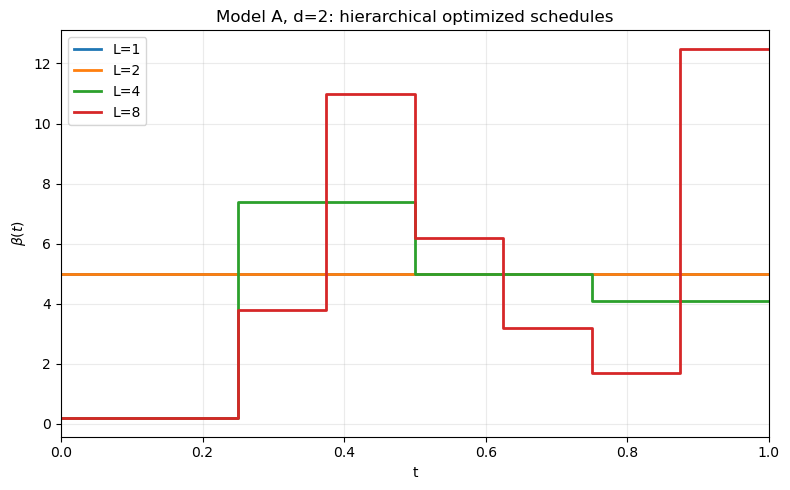

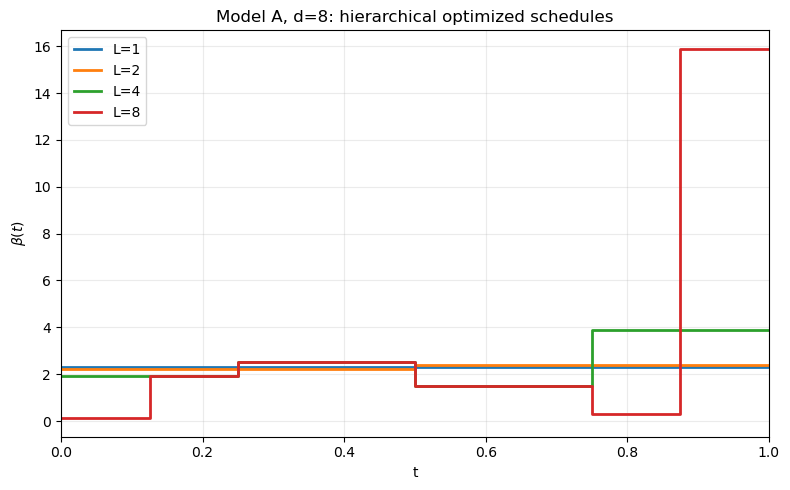

In [15]:
for d in DIMS_MAIN:
    fig, ax = plt.subplots(figsize=(8, 5))
    for L in LEVELS:
        rec = hier_best_records[d][L]["betas"]
        x, y = step_plot_from_betas(rec)
        ax.plot(x, y, linewidth=2, label=f"L={L}")
    ax.set_xlim(0.0, 1.0)
    ax.set_xlabel("t")
    ax.set_ylabel(r"$\beta(t)$")
    ax.set_title(fr"Model A, d={d}: hierarchical optimized schedules")
    ax.legend()
    plt.tight_layout()
    savefig_all(fig, f"fig_modelA_schedule_profiles_d{d}")

### Memory curves: best constant vs best PWC-8

saved: /Users/chertkov/Dropbox/Working/NewPID/NewAdaPID-final/figs/modelA_vgs_main/fig_modelA_best_const_vs_pwc8_Ahat_d2.pdf
saved: /Users/chertkov/Dropbox/Working/NewPID/NewAdaPID-final/figs/modelA_vgs_main/fig_modelA_best_const_vs_pwc8_Ahat_d2.png
saved: /Users/chertkov/Dropbox/Working/NewPID/NewAdaPID-final/figs/modelA_vgs_main/fig_modelA_best_const_vs_pwc8_Ahat_d8.pdf
saved: /Users/chertkov/Dropbox/Working/NewPID/NewAdaPID-final/figs/modelA_vgs_main/fig_modelA_best_const_vs_pwc8_Ahat_d8.png


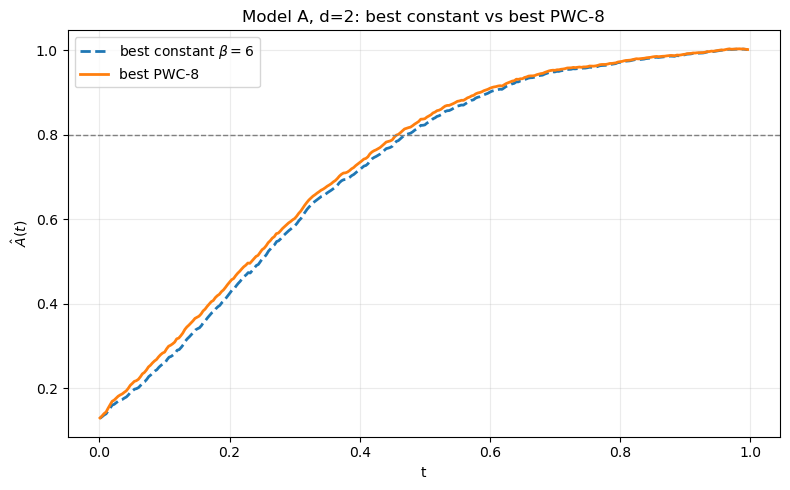

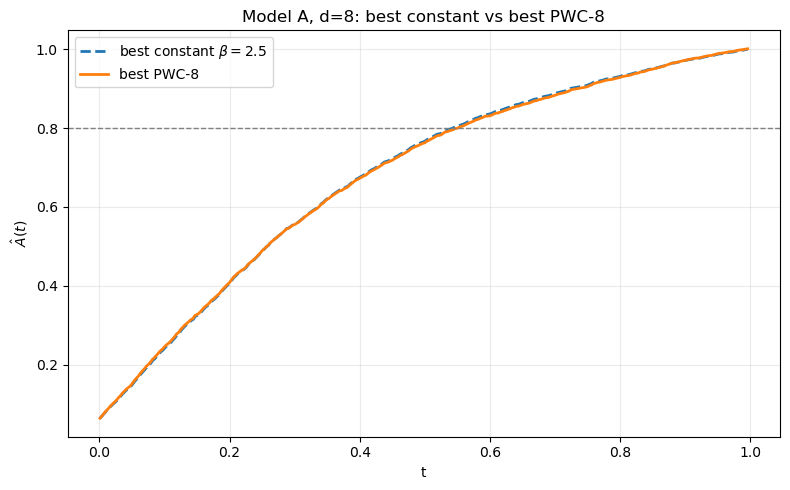

In [16]:
for d in DIMS_MAIN:
    const_row = best_const_df[best_const_df["d"] == d].iloc[0]
    const_beta = float(const_row["beta_const"])
    const_mem = const_artifacts[(d, const_beta)]
    pwc8_mem = hier_best_records[d][8]["mem"]

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(const_mem["times"], const_mem["Ahat"], linewidth=2, linestyle="--", label=fr"best constant $\beta={const_beta:g}$")
    ax.plot(pwc8_mem["times"], pwc8_mem["Ahat"], linewidth=2, label="best PWC-8")
    ax.axhline(0.8, color="gray", linestyle="--", linewidth=1)
    ax.set_xlabel("t")
    ax.set_ylabel(r"$\hat A(t)$")
    ax.set_title(fr"Model A, d={d}: best constant vs best PWC-8")
    ax.legend()
    plt.tight_layout()
    savefig_all(fig, f"fig_modelA_best_const_vs_pwc8_Ahat_d{d}")

### Hierarchical convergence plots

saved: /Users/chertkov/Dropbox/Working/NewPID/NewAdaPID-final/figs/modelA_vgs_main/fig_modelA_hierarchical_convergence_d2.pdf
saved: /Users/chertkov/Dropbox/Working/NewPID/NewAdaPID-final/figs/modelA_vgs_main/fig_modelA_hierarchical_convergence_d2.png
saved: /Users/chertkov/Dropbox/Working/NewPID/NewAdaPID-final/figs/modelA_vgs_main/fig_modelA_hierarchical_convergence_d8.pdf
saved: /Users/chertkov/Dropbox/Working/NewPID/NewAdaPID-final/figs/modelA_vgs_main/fig_modelA_hierarchical_convergence_d8.png


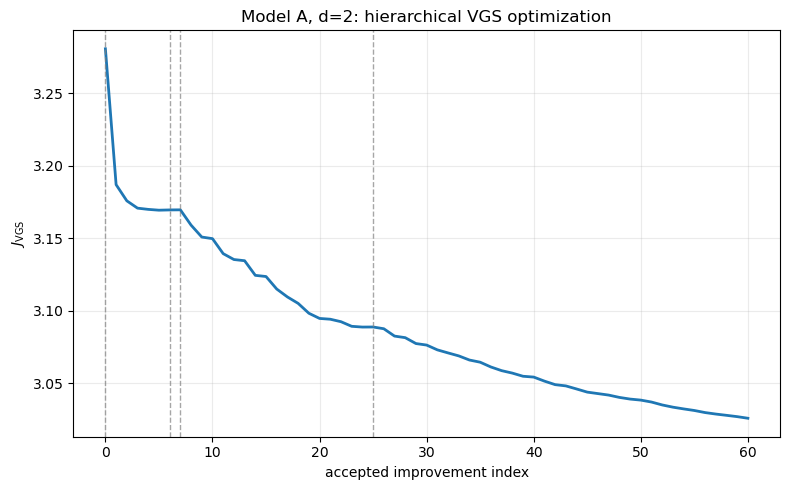

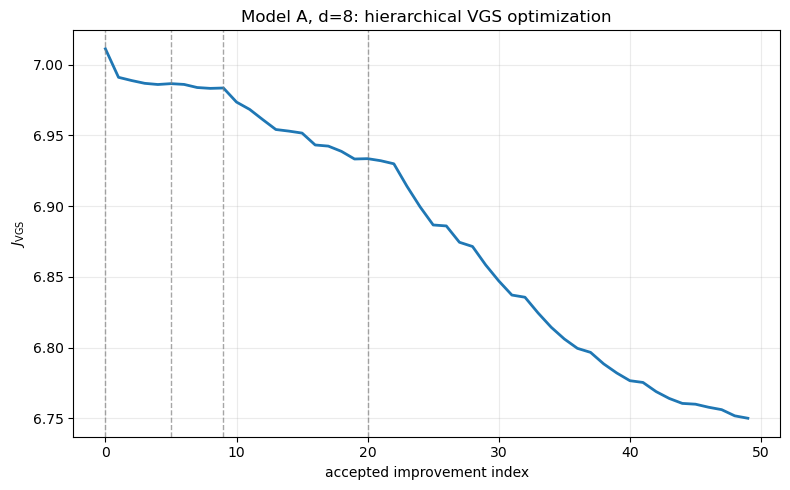

In [17]:
for d in DIMS_MAIN:
    fig, ax = plt.subplots(figsize=(8, 5))
    traj_f = hier_series[d]["traj_f"]
    level_marks = hier_series[d]["level_marks"]
    ax.plot(np.arange(len(traj_f)), traj_f, linewidth=2)
    for m in level_marks:
        ax.axvline(m, color="gray", linestyle="--", linewidth=1, alpha=0.7)
    ax.set_xlabel("accepted improvement index")
    ax.set_ylabel(r"$J_{\mathrm{VGS}}$")
    ax.set_title(fr"Model A, d={d}: hierarchical VGS optimization")
    plt.tight_layout()
    savefig_all(fig, f"fig_modelA_hierarchical_convergence_d{d}")

## Compact scaling study

,d,best_const_beta,best_const_J_VGS_per_d,best_const_t_cross
0,2,6.0,1.640266,0.470119
1,4,2.5,1.084565,0.472854
2,8,2.5,0.876402,0.542512
3,16,1.5,0.689914,0.572028


saved: /Users/chertkov/Dropbox/Working/NewPID/NewAdaPID-final/tables/modelA_vgs_main/scaling_summary_modelA.csv
saved: /Users/chertkov/Dropbox/Working/NewPID/NewAdaPID-final/figs/modelA_vgs_main/fig_modelA_scaling_summary.pdf
saved: /Users/chertkov/Dropbox/Working/NewPID/NewAdaPID-final/figs/modelA_vgs_main/fig_modelA_scaling_summary.png


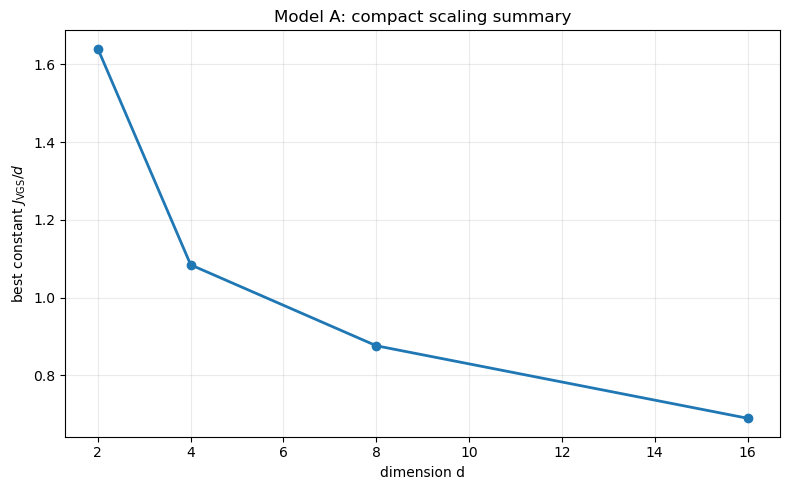

In [18]:
scaling_rows = []
for d in DIMS_SCALING:
    grid = CONST_GRID_BY_D[d]
    rows_d = []
    for beta in grid:
        row, _ = evaluate_vgs_row(d, [beta], kind="scaling_constant", extra={"beta_const": beta})
        rows_d.append(row)

    df_d = pd.DataFrame(rows_d)
    best_d = df_d.sort_values("J_VGS").iloc[0]
    scaling_rows.append({
        "d": d,
        "best_const_beta": float(best_d["beta_const"]),
        "best_const_J_VGS_per_d": float(best_d["J_VGS_per_d"]),
        "best_const_t_cross": float(best_d["t_cross_Ahat_08"]),
    })

scaling_df = pd.DataFrame(scaling_rows).sort_values("d").reset_index(drop=True)
display(scaling_df)
save_table(scaling_df, "scaling_summary_modelA")

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(scaling_df["d"], scaling_df["best_const_J_VGS_per_d"], marker="o", linewidth=2)
ax.set_xlabel("dimension d")
ax.set_ylabel(r"best constant $J_{\mathrm{VGS}}/d$")
ax.set_title("Model A: compact scaling summary")
plt.tight_layout()
savefig_all(fig, "fig_modelA_scaling_summary")

## Manifest

In [19]:
manifest = {
    "repo_root": str(ROOT),
    "model": "A",
    "family": "random diagonal-anisotropic GMM",
    "main_dimensions": DIMS_MAIN,
    "scaling_dimensions": DIMS_SCALING,
    "K": K,
    "radius": RADIUS,
    "scale": SCALE,
    "cond": COND,
    "levels": LEVELS,
    "const_grid_by_d": {str(k): v for k, v in CONST_GRID_BY_D.items()},
    "beta_min": BETA_MIN,
    "beta_max": BETA_MAX,
}
save_json(manifest, "manifest_modelA_vgs_main")

saved: /Users/chertkov/Dropbox/Working/NewPID/NewAdaPID-final/tables/modelA_vgs_main/manifest_modelA_vgs_main.json


Best constant-beta schedule in d=2: [6.]
Best PWC-8 schedule in d=2: [ 0.1875  0.1875  3.7875 10.9875  6.1875  3.1875  1.6875 12.4875]
saved: /Users/chertkov/Dropbox/Working/NewPID/NewAdaPID-final/figs/modelA_vgs_main/fig_modelA_d2_two_row_evolution.pdf
saved: /Users/chertkov/Dropbox/Working/NewPID/NewAdaPID-final/figs/modelA_vgs_main/fig_modelA_d2_two_row_evolution.png


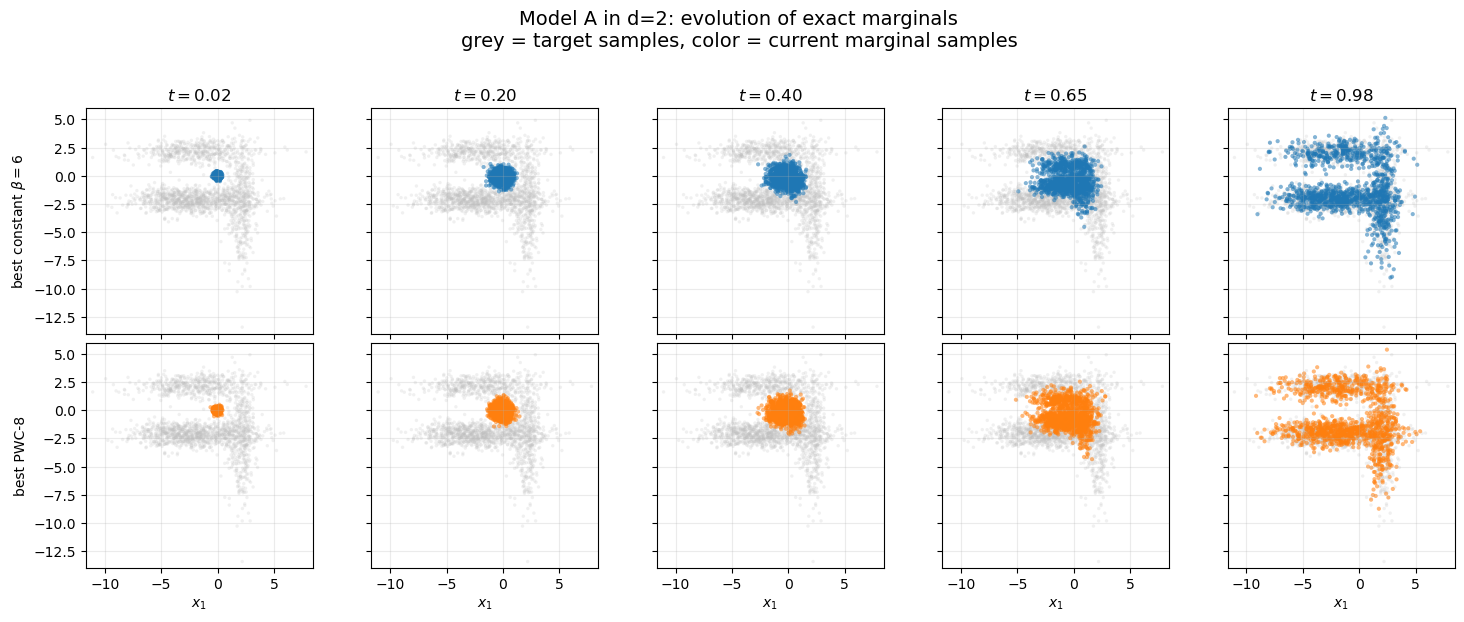

In [21]:
# %% [markdown]
# ### Two-row evolution figure in d=2:
# top = best constant-beta schedule, bottom = best PWC-8 schedule

# %%
import numpy as np
import matplotlib.pyplot as plt

# --- configuration ---
D2_TIMES = [0.02, 0.20, 0.40, 0.65, 0.98]
N_TARGET_SCATTER = 1800
N_CURRENT_SCATTER = 1200
TOP_COLOR = "tab:blue"
BOTTOM_COLOR = "tab:orange"
TARGET_COLOR = "0.75"   # grey
SCATTER_SIZE_TARGET = 6
SCATTER_SIZE_CURRENT = 9
ALPHA_TARGET = 0.22
ALPHA_CURRENT = 0.55

# --- helpers ---
def _extract_gmm_parts(gmm):
    """
    Accept either:
      - dict with keys 'weights','means','covs'
      - object with attributes weights, means, covs
    Return NumPy arrays.
    """
    if isinstance(gmm, dict):
        weights = gmm["weights"]
        means = gmm["means"]
        covs = gmm["covs"]
    else:
        weights = gmm.weights
        means = gmm.means
        covs = gmm.covs

    if hasattr(weights, "detach"):
        weights = weights.detach().cpu().numpy()
    else:
        weights = np.asarray(weights)

    if hasattr(means, "detach"):
        means = means.detach().cpu().numpy()
    else:
        means = np.asarray(means)

    if hasattr(covs, "detach"):
        covs = covs.detach().cpu().numpy()
    else:
        covs = np.asarray(covs)

    weights = np.asarray(weights, dtype=float)
    weights = weights / weights.sum()
    means = np.asarray(means, dtype=float)
    covs = np.asarray(covs, dtype=float)
    return weights, means, covs


def sample_from_gmm(gmm, n, seed=0):
    """
    Simple NumPy mixture sampler from either the target object or an exact marginal GMM dict.
    """
    rng = np.random.default_rng(seed)
    weights, means, covs = _extract_gmm_parts(gmm)
    K = len(weights)
    d = means.shape[1]

    comps = rng.choice(K, size=n, p=weights)
    out = np.empty((n, d), dtype=float)
    for k in range(K):
        idx = np.where(comps == k)[0]
        if len(idx) == 0:
            continue
        out[idx] = rng.multivariate_normal(mean=means[k], cov=covs[k], size=len(idx))
    return out


def axis_limits_from_samples(*arrays, pad=0.7):
    all_xy = np.vstack(arrays)
    xmin, ymin = all_xy.min(axis=0)
    xmax, ymax = all_xy.max(axis=0)
    return (xmin - pad, xmax + pad), (ymin - pad, ymax + pad)


# --- recover best d=2 schedules from the notebook state ---
d = 2

best_const_row_d2 = best_const_df[best_const_df["d"] == d].iloc[0]
best_const_beta_d2 = float(best_const_row_d2["beta_const"])
best_const_schedule_d2 = np.array([best_const_beta_d2], dtype=float)

best_pwc8_schedule_d2 = hier_best_records[d][8]["betas"].copy()

print("Best constant-beta schedule in d=2:", best_const_schedule_d2)
print("Best PWC-8 schedule in d=2:", best_pwc8_schedule_d2)

# --- build target and PIDs using the actual notebook API ---
target_d2 = build_target(d)
pid_const_d2 = build_pid(d, best_const_schedule_d2)
pid_pwc8_d2 = build_pid(d, best_pwc8_schedule_d2)

# --- sample target once and reuse in every panel ---
target_samples = sample_from_gmm(target_d2, N_TARGET_SCATTER, seed=2025)

# --- precompute current marginal samples at chosen times ---
const_samples_by_t = {}
pwc_samples_by_t = {}

for j, t in enumerate(D2_TIMES):
    gm_const = exact_marginal_gmm(pid_const_d2, float(t))
    gm_pwc = exact_marginal_gmm(pid_pwc8_d2, float(t))

    const_samples_by_t[t] = sample_from_gmm(gm_const, N_CURRENT_SCATTER, seed=3100 + j)
    pwc_samples_by_t[t] = sample_from_gmm(gm_pwc, N_CURRENT_SCATTER, seed=4100 + j)

# --- choose common axis limits across all panels ---
all_current = [const_samples_by_t[t] for t in D2_TIMES] + [pwc_samples_by_t[t] for t in D2_TIMES]
xlim, ylim = axis_limits_from_samples(target_samples, *all_current, pad=0.6)

# --- make figure ---
fig, axes = plt.subplots(
    2, len(D2_TIMES),
    figsize=(3.0 * len(D2_TIMES), 6.0),
    sharex=True, sharey=True
)

row_titles = [
    rf"best constant $\beta={best_const_beta_d2:g}$",
    r"best PWC-8"
]

for col, t in enumerate(D2_TIMES):
    # top row: best constant-beta
    ax = axes[0, col]
    ax.scatter(
        target_samples[:, 0], target_samples[:, 1],
        s=SCATTER_SIZE_TARGET, c=TARGET_COLOR, alpha=ALPHA_TARGET, edgecolors="none"
    )
    xs = const_samples_by_t[t]
    ax.scatter(
        xs[:, 0], xs[:, 1],
        s=SCATTER_SIZE_CURRENT, c=TOP_COLOR, alpha=ALPHA_CURRENT, edgecolors="none"
    )
    ax.set_title(rf"$t={t:.2f}$")
    if col == 0:
        ax.set_ylabel(row_titles[0])

    # bottom row: best PWC-8
    ax = axes[1, col]
    ax.scatter(
        target_samples[:, 0], target_samples[:, 1],
        s=SCATTER_SIZE_TARGET, c=TARGET_COLOR, alpha=ALPHA_TARGET, edgecolors="none"
    )
    xs = pwc_samples_by_t[t]
    ax.scatter(
        xs[:, 0], xs[:, 1],
        s=SCATTER_SIZE_CURRENT, c=BOTTOM_COLOR, alpha=ALPHA_CURRENT, edgecolors="none"
    )
    if col == 0:
        ax.set_ylabel(row_titles[1])
    ax.set_xlabel(r"$x_1$")

for ax in axes.ravel():
    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    ax.set_aspect("equal", adjustable="box")

fig.suptitle(
    "Model A in d=2: evolution of exact marginals\n"
    "grey = target samples, color = current marginal samples",
    y=1.02,
    fontsize=14
)
plt.tight_layout()

savefig_all(fig, "fig_modelA_d2_two_row_evolution")
plt.show()